<a href="https://colab.research.google.com/github/himanshv22/California-Housing-Clustering-Analysis/blob/main/california_housing_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Read the dataset, split it, apply feature scaling then plot it using scatter plot


<Axes: xlabel='longitude', ylabel='latitude'>

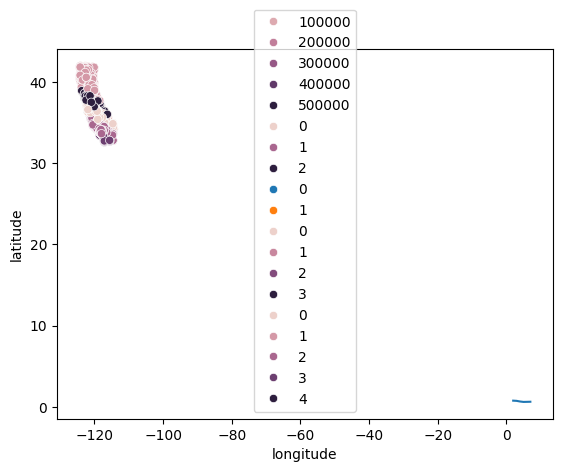

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

home_data=pd.read_csv('california_housing_prices.csv', usecols=['longitude','latitude','median_house_value'])
home_data.head()
sns.scatterplot(data=home_data,x='longitude', y='latitude', hue='median_house_value')
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(home_data[['latitude','longitude']],home_data[['median_house_value']],test_size=0.33, random_state=0)

from sklearn import preprocessing
X_train_norm=preprocessing.normalize(X_train)
X_test_norm=preprocessing.normalize(X_test)

from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(X_train_norm)
sns.scatterplot(data=X_train,x='longitude', y='latitude', hue=kmeans.labels_)

from sklearn.metrics import silhouette_score
silhouette_score(X_train_norm,kmeans.labels_,metric='euclidean')

K=range(2,8)
fits=[]
score=[]
for k in K:
  model=KMeans(n_clusters=k,random_state=0,n_init='auto').fit(X_train_norm)
  fits.append(model)
  score.append(silhouette_score(X_train_norm,model.labels_,metric='euclidean'))
sns.scatterplot(data=X_train,x='longitude', y='latitude', hue=fits[0].labels_)
sns.scatterplot(data=X_train,x='longitude', y='latitude', hue=fits[2].labels_)
sns.lineplot(x=K,y=score)
sns.scatterplot(data=X_train,x='longitude', y='latitude', hue=fits[3].labels_)

